# **Perbandingan Semua Tokenizer**

# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns  

from transformers import BartTokenizer

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Load Dataset

In [2]:
# mix_datasets_8k_path = kagglehub.dataset_download('jawahirul/mix-datasets-8k')

df = pd.read_csv('/kaggle/input/fine-tuning/fine-tuning.csv')

documents = df['text'].tolist()

# Evaluasi Tokenizer

## Check Total Token

In [3]:
original_bart = BartTokenizer.from_pretrained('facebook/bart-base')
indomixedtufs4_50k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-indomixedtufs4/transformers/tokenizer-indomixedtufs4-50265/1')
detiknews_50k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-detiknews-pemilu/transformers/tokenizer-detiknews-pemilu-50265/1')
mix_50k = BartTokenizer.from_pretrained('/kaggle/input/tokenizer-mix/transformers/tokenizer-mix-50265/1')

# Fungsi untuk menghitung total kata dan token
def total_token(documents):
    word_counts = []
    original_counts = []
    indomixedtufs4_counts = []
    detiknews_counts = []
    mix_counts = []

    for doc in documents:
            
        # Hitung jumlah kata dengan NLTK
        words = word_tokenize(doc)
        word_counts.append(len(words))

        # Hitung jumlah token dengan custom tokenizer
        original_token = original_bart.encode(doc, add_special_tokens=False)
        original_counts.append(len(original_token))

        indomixedtufs4_token = indomixedtufs4_50k.encode(doc, add_special_tokens=False)
        indomixedtufs4_counts.append(len(indomixedtufs4_token))

        detiknews_token = detiknews_50k.encode(doc, add_special_tokens=False)
        detiknews_counts.append(len(detiknews_token))

        mix_token = mix_50k.encode(doc, add_special_tokens=False)
        mix_counts.append(len(mix_token))

    # Hitung total kata
    total_word_count = sum(word_counts)
    total_original = sum(original_counts)
    total_indomixedtufs4 = sum(indomixedtufs4_counts)
    total_detiknews = sum(detiknews_counts)
    total_mix = sum(mix_counts)

    return total_word_count, total_original, total_indomixedtufs4, total_detiknews, total_mix



vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

In [4]:
# Format output ke ribuan
def format_thousands(number):
    return "{:,}".format(int(number)).replace(",", ".")

# Hitung total kata dan token
total_word_count, total_original, total_indomixedtufs4, total_detiknews, total_mix = total_token(documents)

# Print hasil
print(f"Total kata (NLTK): {format_thousands(total_word_count)}")
print(f"Total token BART Original: {format_thousands(total_original)}")
print(f"Total token indomixedtufs4: {format_thousands(total_indomixedtufs4)}")
print(f"Total token detiknews-pemilu: {format_thousands(total_detiknews)}")
print(f"Total token mix: {format_thousands(total_mix)}")

Total kata (NLTK): 3.798.826
Total token BART Original: 8.886.348
Total token indomixedtufs4: 4.418.597
Total token detiknews-pemilu: 4.313.864
Total token mix: 4.189.544


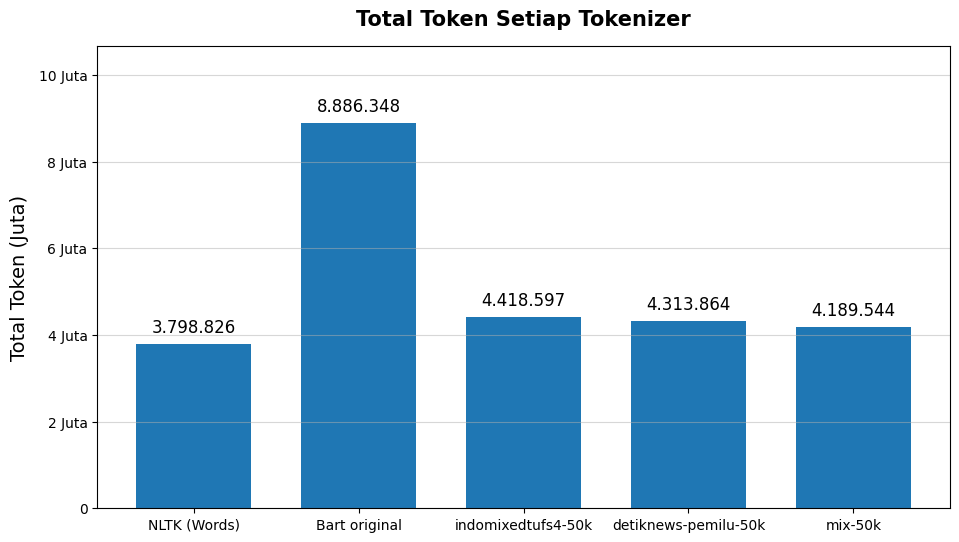

In [5]:
# Fungsi untuk visualisasi
def plot_total_token(total_word_count, total_original, total_indomixedtufs4, total_detiknews, total_mix):
    labels = ['NLTK (Words)', 'Bart original', 'indomixedtufs4-50k', 'detiknews-pemilu-50k', 'mix-50k']
    values = [total_word_count, total_original, total_indomixedtufs4, total_detiknews, total_mix]

    plt.figure(figsize=(11, 6))
    bars = plt.bar(labels, values, width=0.7)
    
    # Menambahkan judul dan label
    plt.title('Total Token Setiap Tokenizer', fontweight='semibold', fontsize=15, pad=15)
    plt.ylabel('Total Token (Juta)', fontsize=14, labelpad=7)
    # plt.xlabel('Tokenization Method', fontsize=13, labelpad=20)

    # Set grid dan panjang bar
    plt.grid(True, axis='y', alpha=0.5)
    plt.ylim(0, max(values) * 1.2) # mengatur panjang bar

    # Tambahkan nilai di atas setiap bar
    for i, v in enumerate(values):
        plt.text(i, v + max(values)*0.03, format_thousands(v), ha='center', fontsize=12)

    def juta_formatter(x, pos):
        """Mengubah angka tick menjadi format jutaan (misal: 2 Jt, 5.5 Jt)"""
        if x == 0:
            return '0'
        else:
            val_jt = x / 1e6
            # Jika nilainya adalah bilangan bulat setelah dibagi sejuta (misal 2.0, 3.0)
            # tampilkan tanpa desimal. Jika tidak (misal 2.5), tampilkan satu desimal.
            if val_jt == int(val_jt):
                return f'{val_jt:.0f} Juta'
            else:
                return f'{val_jt:.1f} Juta'

    # Dapatkan axes saat ini dan terapkan formatter ke sumbu Y
    ax = plt.gca()
    ax.yaxis.set_major_formatter(FuncFormatter(juta_formatter))

    plt.show()

#Visualisasi hasil
plot_total_token(total_word_count, total_original, total_indomixedtufs4, total_detiknews, total_mix)


## Fertility Metric

In [6]:
# Fungsi   menghitung metrik fertility dari total token
def fertility_metric(total_word_count, total_original, total_indomixedtufs4, total_detiknews, total_mix):
    # Hitung fertility (total token / total kata asli)
    fertility_original = total_original / total_word_count
    fertility_indomixedtufs4 = total_indomixedtufs4 / total_word_count 
    fertility_detiknews = total_detiknews / total_word_count
    fertility_mix = total_mix / total_word_count

    return fertility_original, fertility_indomixedtufs4, fertility_detiknews, fertility_mix

In [7]:
# Hitung fertility dari total
fertility_original, fertility_indomixedtufs4, fertility_detiknews, fertility_mix = fertility_metric(
    total_word_count, total_original, total_indomixedtufs4, total_detiknews, total_mix
)
    
# Print hasil fertility
print(f"Fertility (original bart): {fertility_original:.2f}")
print(f"Fertility (indomixedtufs4-50k): {fertility_indomixedtufs4:.2f}")
print(f"Fertility (detiknews-pemilu-50k): {fertility_detiknews:.2f}")
print(f"Fertility (mix-50k): {fertility_mix:.2f}")


Fertility (original bart): 2.34
Fertility (indomixedtufs4-50k): 1.16
Fertility (detiknews-pemilu-50k): 1.14
Fertility (mix-50k): 1.10


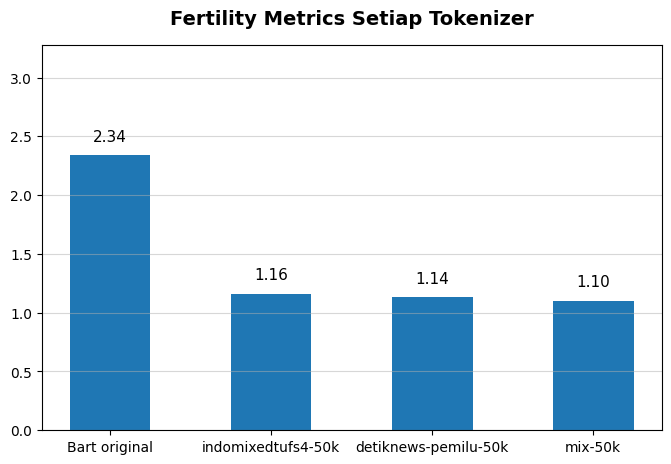

In [8]:
# Fungsi visualisasi fertility
def plot_fertility(fertility_original, fertility_indomixedtufs4, fertility_detiknews, fertility_mix):
    labels = ['Bart original', 'indomixedtufs4-50k', 'detiknews-pemilu-50k', 'mix-50k']
    values = [fertility_original, fertility_indomixedtufs4, fertility_detiknews, fertility_mix]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, width=0.5)

    # Set Judul dan label
    plt.title('Fertility Metrics Setiap Tokenizer', fontweight='semibold', fontsize=14, pad=15)
    # plt.ylabel('Tokens per Word', fontsize=13, labelpad=20)
    # plt.xlabel('Tokenizer', fontsize=13, labelpad=20)

    # Set grid dan panjang bar
    plt.grid(True, axis='y', alpha=0.5)
    plt.ylim(0, max(values) * 1.4) # Mengatur panjang bar

    # Tambahkan nilai di atas setiap bar
    for i, v in enumerate(values):
        plt.text(i, v + max(values)*0.05, f"{v:.2f}", ha='center', fontsize=11)

    plt.show()

# Visualisasi fertility
plot_fertility(fertility_original, fertility_indomixedtufs4, fertility_detiknews, fertility_mix)